### 1. Cài đặt các thư viện cần thiết
Chúng ta sử dụng `open-clip-torch` cho mô hình CLIP và `faiss-cpu` để hỗ trợ tìm kiếm (retrieval) nhanh chóng.

In [1]:
!pip install open-clip-torch faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Kết nối Google Drive và Giải nén dữ liệu
Để tối ưu tốc độ đọc ảnh (I/O), chúng ta giải nén từ Drive vào bộ nhớ tạm của Colab (`/content/`).

In [6]:
import os
import zipfile
from google.colab import drive

# Cấu hình đường dẫn
IMAGE_ZIP = '/content/drive/MyDrive/TTTN/clothesimage.zip'
IMAGE_EXTRACT_PATH = '/content/clothes_images'
CSV_PATH = '//content/drive/MyDrive/TTTN/data.csv'

# Giải nén
if not os.path.exists(IMAGE_EXTRACT_PATH):
    if os.path.exists(IMAGE_ZIP):
        print("Đang giải nén ảnh vào local runtime...")
        with zipfile.ZipFile(IMAGE_ZIP, 'r') as zip_ref:
            zip_ref.extractall(IMAGE_EXTRACT_PATH)
        print("Hoàn thành giải nén.")
    else:
        print(f"Lỗi: Không tìm thấy file zip tại {IMAGE_ZIP}")
else:
    print("Ảnh đã tồn tại trong local runtime.")

Đang giải nén ảnh vào local runtime...
Hoàn thành giải nén.


### 3. Tiền xử lý văn bản và Định nghĩa Dataset
Chúng ta giữ lại các thông tin quan trọng như màu sắc, chất liệu và thương hiệu trong domain thời trang.

### 3.1 Cập nhật Augmentation cho Train set
Thêm các kỹ thuật tăng cường dữ liệu ảnh để mô hình tổng quát hóa tốt hơn.

In [7]:
import re
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image

def clean_fashion_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Giữ lại các thuộc tính quan trọng: màu sắc, chất liệu, giới tính
    # Loại bỏ các từ dừng (stopwords) không mang ý nghĩa tìm kiếm thời trang
    text = re.sub(r"'s", "", text)
    text = re.sub(r"[^\w\s-]", " ", text)

    # Loại bỏ các từ rác phổ biến trong dataset nếu có
    garbage_words = ['click', 'here', 'buy', 'now', 'zoom', 'image']
    for word in garbage_words:
        text = text.replace(word, '')

    text = " ".join(text.split())
    return text

class FashionDataset(Dataset):
    def __init__(self, df, transform, tokenizer):
        self.images = df['image_path_in_local'].values
        # Áp dụng hàm clean mới
        self.texts = df['description'].apply(clean_fashion_text).values
        self.transform = transform
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            image = self.transform(Image.open(self.images[idx]).convert('RGB'))
            text = self.tokenizer(self.texts[idx])[0]
            return image, text
        except Exception as e:
            # Trả về mẫu đầu tiên nếu ảnh lỗi để tránh dừng training
            return self.__getitem__(0)

In [8]:
import torch
import open_clip

def build_model():
    # Sử dụng weights laion2b
    model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
    tokenizer = open_clip.get_tokenizer('ViT-B-32')
    return model, preprocess, tokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess, tokenizer = build_model()
model.to(device)

print(f"Mô hình đã được tải trên thiết bị: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Mô hình đã được tải trên thiết bị: cuda


In [10]:
from torchvision import transforms

# Augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
])

val_transform = preprocess

In [11]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from glob import glob

# 1. Đọc dataframe
df = pd.read_csv(CSV_PATH)
print(f"Các cột hiện có: {df.columns.tolist()}")

# 2. Quét toàn bộ file ảnh thực tế
print("Đang quét thư mục ảnh...")
all_image_paths = glob(os.path.join(IMAGE_EXTRACT_PATH, '**', '*.*'), recursive=True)
all_image_paths = [f for f in all_image_paths if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Tạo mapping linh hoạt: { 'tên_không_extension': 'đường/dẫn/đầy/đủ' }
image_map = {}
for p in all_image_paths:
    base = os.path.basename(p).lower()
    name_only = os.path.splitext(base)[0]
    image_map[base] = p
    image_map[name_only] = p

print(f"Tìm thấy {len(all_image_paths)} ảnh local.")

# 3. Ánh xạ đường dẫn
def resolve_path(row):
    # Thử các cột có khả năng chứa thông tin file local trước
    for col in ['local_image_path', 'image', 'clean_name']:
        if col in row and pd.notna(row[col]):
            val = str(row[col]).strip().lower()
            # Lấy tên file từ URL hoặc path
            fname = os.path.basename(val).split('?')[0]
            fname_no_ext = os.path.splitext(fname)[0]

            if fname in image_map: return image_map[fname]
            if fname_no_ext in image_map: return image_map[fname_no_ext]
    return ""

df['image_path_in_local'] = df.apply(resolve_path, axis=1)

# 4. Kiểm tra cột description
if 'description' not in df.columns and 'name' in df.columns:
    df['description'] = df['name']

# 5. Lọc và Chia data
df_filtered = df[df['image_path_in_local'] != ""].reset_index(drop=True)
print(f"Tổng số mẫu khớp thành công: {len(df_filtered)}")

if len(df_filtered) > 0:
    df = df_filtered
    print(f"Ví dụ khớp: {df['image_path_in_local'].iloc[0]}")
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
    print(f"Chia data: Train({len(train_df)}), Val({len(val_df)}), Test({len(test_df)})")
else:
    print("Lỗi: Không tìm thấy ảnh tương ứng. Vui lòng kiểm tra lại cấu trúc thư mục clothes_images.")
    # Debug: In ra cấu trúc thư mục thực tế
    !ls -R {IMAGE_EXTRACT_PATH} | head -n 10

Các cột hiện có: ['name', 'image', 'link', 'local_image_path', 'clean_name']
Đang quét thư mục ảnh...
Tìm thấy 24735 ảnh local.
Tổng số mẫu khớp thành công: 12288
Ví dụ khớp: /content/clothes_images/clothesimage/0.jpg
Chia data: Train(9830), Val(1229), Test(1229)


In [15]:
df_filtered.tail(1)

,name,image,link,local_image_path,clean_name,image_path_in_local,description
12287,Nike Men's Athletic The Tee Crew Neck Short Sl...,https://m.media-amazon.com/images/I/71itioqX2U...,https://www.amazon.in/Nike-Athletic-Short-Slee...,/content/drive/MyDrive/TTTN/clothesimage/32209...,nike men's athletic the tee crew neck short sl...,/content/clothes_images/clothesimage/32209.jpg,Nike Men's Athletic The Tee Crew Neck Short Sl...



--- MỘT SỐ DÒNG NGẪU NHIÊN TRONG DATASET ---


,name,image,link,image_path_in_local
11432,Design Cafe Men's Tshirt Half Sleeves Round Ne...,https://m.media-amazon.com/images/I/61mhvG5MEC...,https://www.amazon.in/Design-Cafe-Sleeves-Prin...,/content/clothes_images/clothesimage/29888.jpg



--- HIỂN THỊ ẢNH TỪ DÒNG NGẪU NHIÊN ---
Đang hiển thị ảnh từ: /content/clothes_images/clothesimage/29888.jpg


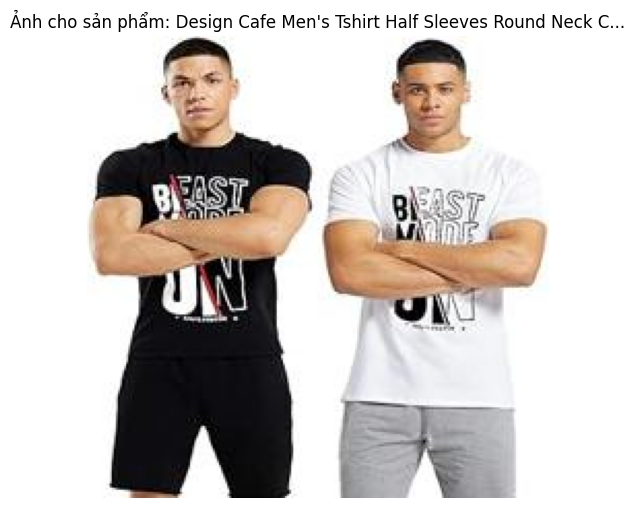

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# 1. In random vài dòng trong dataset
print("\n--- MỘT SỐ DÒNG NGẪU NHIÊN TRONG DATASET ---")
random_rows = df.sample(n=1, random_state=36)
display(random_rows[['name', 'image', 'link', 'image_path_in_local']])

# 2. In ảnh từ một trong các dòng ngẫu nhiên đó
print("\n--- HIỂN THỊ ẢNH TỪ DÒNG NGẪU NHIÊN ---")
# Chọn dòng đầu tiên trong các dòng ngẫu nhiên để hiển thị ảnh
sample_row = random_rows.iloc[0]

image_to_display = None
# Ưu tiên 'image_path_in_local' vì đã được xử lý và xác nhận tồn tại trong các bước trước
if 'image_path_in_local' in sample_row and pd.notna(sample_row['image_path_in_local']):
    image_to_display = sample_row['image_path_in_local']
elif 'local_image_path' in sample_row and pd.notna(sample_row['local_image_path']):
    # Fallback to 'local_image_path' if 'image_path_in_local' is not available
    image_to_display = sample_row['local_image_path']

if image_to_display and os.path.exists(image_to_display):
    print(f"Đang hiển thị ảnh từ: {image_to_display}")
    img = Image.open(image_to_display)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Ảnh cho sản phẩm: {sample_row['name'][:50]}...")
    plt.axis('off')
    plt.show()
else:
    print(f"Không tìm thấy ảnh tại đường dẫn: {image_to_display}")
    print("Vui lòng kiểm tra lại đường dẫn ảnh hoặc đảm bảo các bước giải nén và ánh xạ đường dẫn đã thành công.")

In [24]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

# Khởi tạo Dataset và DataLoader
train_dataset = FashionDataset(train_df, train_transform, tokenizer)
val_dataset = FashionDataset(val_df, val_transform, tokenizer)

# 1. Tăng Batch Size lên mức tối đa VRAM cho phép (thử 64 hoặc 128)
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

epochs = 10

# 2. Cấu hình Optimizer với Weight Decay tốt hơn
# Chúng ta cho phép cập nhật toàn bộ tham số của CLIP
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.2)

# 3. Sử dụng Cosine Annealing Scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

# 4. Label Smoothing Loss (giảm Overfitting vào text mô tả thô)
def contrastive_loss(logits_per_image, logits_per_text, device):
    labels = torch.arange(len(logits_per_image), device=device)
    # Sử dụng CrossEntropy tiêu chuẩn nhưng có thể thêm label_smoothing=0.1
    loss_i = torch.nn.functional.cross_entropy(logits_per_image, labels, label_smoothing=0.1)
    loss_t = torch.nn.functional.cross_entropy(logits_per_text, labels, label_smoothing=0.1)
    return (loss_i + loss_t) / 2

print(f"Đã cập nhật cấu hình: Batch Size={BATCH_SIZE}, LR=1e-5 với Cosine Scheduler.")

Đã cập nhật cấu hình: Batch Size=64, LR=1e-5 với Cosine Scheduler.


In [25]:
# Khởi tạo lại Dataset và DataLoader với quy trình clean text và augmentation mới
train_dataset = FashionDataset(train_df, train_transform, tokenizer)
val_dataset = FashionDataset(val_df, val_transform, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"DataLoaders đã sẵn sàng với {len(train_dataset)} mẫu huấn luyện.")

DataLoaders đã sẵn sàng với 9830 mẫu huấn luyện.


### 8.1 Chạy Huấn luyện và Vẽ biểu đồ Loss

In [26]:
from tqdm.auto import tqdm

# Huấn luyện mô hình
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
counter = 0
patience = 5 # Tăng patience vì LR scheduler cần thời gian

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for images, texts in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, texts = images.to(device), texts.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            image_features, text_features, logit_scale = model(images, texts)
            logits_per_image = logit_scale * image_features @ text_features.t()
            logits_per_text = logits_per_image.t()
            loss = contrastive_loss(logits_per_image, logits_per_text, device)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_train_loss += loss.item()

    # Update Scheduler
    scheduler.step()

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, texts in val_loader:
            images, texts = images.to(device), texts.to(device)
            with torch.amp.autocast(device_type='cuda'):
                if len(images) < 2: continue # Tránh lỗi batch 1
                img_feat, txt_feat, scale = model(images, texts)
                l_i = scale * img_feat @ txt_feat.t()
                l_t = l_i.t()
                v_loss = contrastive_loss(l_i, l_t, device)
                total_val_loss += v_loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)

    print(f"Epoch {epoch+1}: Train={avg_train:.4f}, Val={avg_val:.4f}, LR={scheduler.get_last_lr()[0]:.2e}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'best_model_optimized.pt')
        print("⭐ New Best Model Saved")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1:   0%|          | 0/153 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    if w.is_alive():^
^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process' 
  ^ ^  ^^  ^ ^ ^ ^ ^ ^^^^^^
  File "/

Epoch 1: Train=2.3752, Val=2.0660, LR=9.76e-06
⭐ New Best Model Saved


Epoch 2:   0%|          | 0/153 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20>^
^^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^^^if w.is_alive():^^
 ^ ^  ^^^^ ^

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
    Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    self._shutdown_workers()^^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^^if w.is_alive():
 ^^^  ^ ^ ^ ^ ^^^^^^^^^^

Epoch 9: Train=0.9866, Val=1.6628, LR=2.45e-07
⭐ New Best Model Saved


Epoch 10:   0%|          | 0/153 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^^    ^self._shutdown_workers()^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    if w.is_alive():^^
 ^ ^ 

Epoch 10: Train=0.9744, Val=1.6607, LR=0.00e+00
⭐ New Best Model Saved


In [27]:
# Restart training loop with the new data pipeline
# Reset optimizer and scheduler for a fresh start on the refined data
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.2)
scheduler = CosineAnnealingLR(optimizer, T_max=15) # Tập trung fine-tune nhanh
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

print("Bắt đầu huấn luyện tinh chỉnh (Fine-tuning phase 2)...")

Bắt đầu huấn luyện tinh chỉnh (Fine-tuning phase 2)...


In [28]:
# Tiᚙp tục huấn luyện Phase 2 vối Data Augmentation mạnh và Text đã được làm sạch
import torch
from tqdm.auto import tqdm

# Đảm bảo thiết bị được định nghĩa
device = "cuda" if torch.cuda.is_available() else "cpu"

history_phase2 = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
epochs_p2 = 20
patience_p2 = 5
counter = 0

print(f"Đang thực hiện Fine-tuning Phase 2 tràn thiết bị: {device}")

for epoch in range(epochs_p2):
    model.train()
    total_train_loss = 0

    for images, texts in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, texts = images.to(device), texts.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda' if "cuda" in device else "cpu"):
            image_features, text_features, logit_scale = model(images, texts)
            logits_per_image = logit_scale * image_features @ text_features.t()
            logits_per_text = logits_per_image.t()
            # Sử dụng hàm loss đã định nghĩa ở cell 1a2d82fa
            loss = contrastive_loss(logits_per_image, logits_per_text, device)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_train_loss += loss.item()

    scheduler.step()

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, texts in val_loader:
            images, texts = images.to(device), texts.to(device)
            with torch.amp.autocast(device_type='cuda' if "cuda" in device else "cpu"):
                if len(images) < 2: continue
                img_feat, txt_feat, scale = model(images, texts)
                l_i = scale * img_feat @ txt_feat.t()
                l_t = l_i.t()
                v_loss = contrastive_loss(l_i, l_t, device)
                total_val_loss += v_loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)
    history_phase2['train_loss'].append(avg_train)
    history_phase2['val_loss'].append(avg_val)

    print(f"Epoch {epoch+1}: Train={avg_train:.4f}, Val={avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'best_model_optimized_v2.pt')
        print("⭐ Đã lưu trọng số Phase 2 tốt nhất!")
        counter = 0
    else:
        counter += 1
        if counter >= patience_p2:
            print("Dừng sớm do không cải thiện thàm.")
            break

Đang thực hiện Fine-tuning Phase 2 tràn thiết bị: cuda


Epoch 1:   0%|          | 0/153 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20>
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e36a7d77e20>    self._shutdown_workers()

    Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
if w.is_alive():    
self._shutdown_workers()  
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
    ^^ ^ ^ ^ ^ ^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^  
   File "/usr/lib/

Epoch 1: Train=1.1416, Val=1.7705
⭐ Đã lưu trọng số Phase 2 tốt nhất!


Epoch 2:   0%|          | 0/153 [00:00<?, ?it/s]

...

Epoch 10: Train=0.8599, Val=1.7276


Epoch 11:   0%|          | 0/153 [00:00<?, ?it/s]

Epoch 11: Train=0.8519, Val=1.7379


Epoch 12:   0%|          | 0/153 [00:00<?, ?it/s]

Epoch 12: Train=0.8473, Val=1.7445
Dừng sớm do không cải thiện thàm.


### 9. Trích xuất Embedding và Xây dựng FAISS Index

In [38]:
import faiss
import numpy as np
import os
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

def extract_embeddings(model, loader, device):
    model.eval()
    all_features = []
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Đang trích xuất features"):
            images = images.to(device)
            features = model.encode_image(images)
            features /= features.norm(dim=-1, keepdim=True)
            all_features.append(features.cpu().numpy())
    return np.vstack(all_features)

# Nạp trọng số từ quá trình tối ưu mới nhất
optimized_path = "best_model_optimized_v2.pt"
if os.path.exists(optimized_path):
    model.load_state_dict(torch.load(optimized_path, map_location=device))
    print(f"✅ Đã nạp thành công: {optimized_path}")
else:
    if os.path.exists("best_model.pt"):
        model.load_state_dict(torch.load("best_model.pt", map_location=device))
        print("⚠️ Đang sử dụng best_model.pt cũ.")

full_dataset = FashionDataset(df, preprocess, tokenizer)
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=2)

image_embeddings = extract_embeddings(model, full_loader, device)

dimension = image_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(image_embeddings.astype('float32'))

print(f"🚀 Retrieval Index đã sẵn sàng với trọng số mới!")

✅ Đã nạp thành công: best_model_optimized_v2.pt


Đang trích xuất features:   0%|          | 0/192 [00:00<?, ?it/s]

🚀 Retrieval Index đã sẵn sàng với trọng số mới!


### 11. Chạy thử nghiệm Tìm kiếm thực tế
Sử dụng hàm `search_fashion` để tìm sản phẩm dựa trên mô tả văn bản và hiển thị kết quả kèm hình ảnh.

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Kết quả tìm kiếm cho: 'yellow clothing shirt boy'


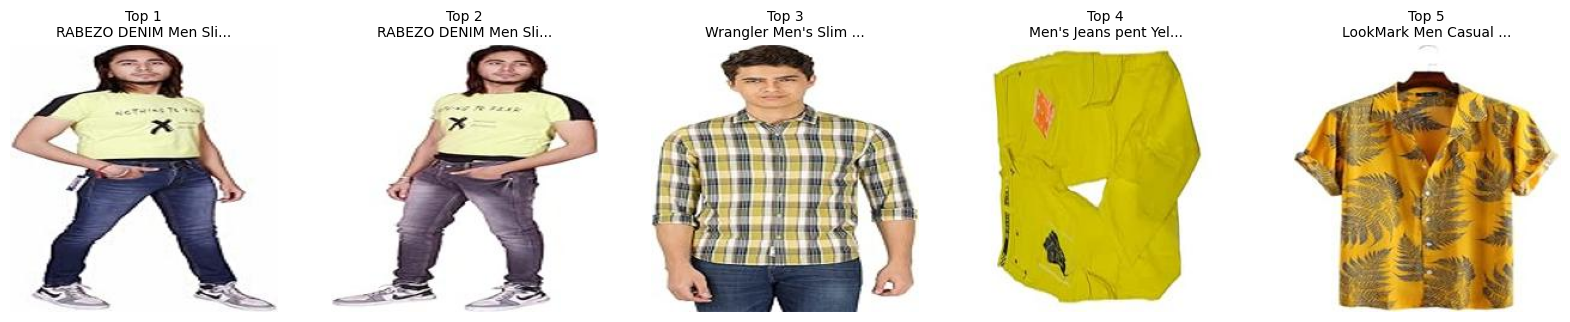

,name,description,image_path_in_local
2557,RABEZO DENIM Men Slim Fit Jeans Latest Mens Jean,RABEZO DENIM Men Slim Fit Jeans Latest Mens Jean,/content/clothes_images/clothesimage/6968.jpg
1308,RABEZO DENIM Men Slim Fit Jeans Grey Mens Jean,RABEZO DENIM Men Slim Fit Jeans Grey Mens Jean,/content/clothes_images/clothesimage/3139.jpg
4030,Wrangler Men's Slim Jeans (WMSH004523_Light In...,Wrangler Men's Slim Jeans (WMSH004523_Light In...,/content/clothes_images/clothesimage/12079.jpg
5825,Men's Jeans pent Yellow Color,Men's Jeans pent Yellow Color,/content/clothes_images/clothesimage/16265.jpg
6527,LookMark Men Casual Shirts,LookMark Men Casual Shirts,/content/clothes_images/clothesimage/17601.jpg


In [39]:
import matplotlib.pyplot as plt
from PIL import Image

# Định nghĩa hàm tìm kiếm (Đảm bảo đã chạy các cell khởi tạo model và index trước đó)
def search_fashion(query_text, top_k=5):
    text_tokens = tokenizer([clean_fashion_text(query_text)]).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    query_vector = text_features.cpu().numpy().astype('float32')
    distances, indices = index.search(query_vector, top_k)
    return df.iloc[indices[0]]

def display_results(query, results):
    print(f"Kết quả tìm kiếm cho: '{query}'")
    plt.figure(figsize=(20, 10))

    for i, (idx, row) in enumerate(results.iterrows()):
        plt.subplot(1, len(results), i + 1)
        try:
            img = Image.open(row['image_path_in_local'])
            plt.imshow(img)
            plt.title(f"Top {i+1}\n{row['name'][:20]}...", fontsize=10)
        except Exception as e:
            plt.title(f"Lỗi tải ảnh")
        plt.axis('off')
    plt.show()

    # Hiển thị thông tin chi tiết
    display(results[['name', 'description', 'image_path_in_local']])

# --- THỰC HIỆN TÌM KIẾM ---
query = "yellow clothing shirt boy"
top_results = search_fashion(query, top_k=5)
display_results(query, top_results)

In [40]:
import numpy as np
import torch
from tqdm.auto import tqdm

def evaluate_retrieval(model, df_test, index, tokenizer, device, ks=[1, 5, 10, 20]):
    model.eval()

    # 1. Trích xuất embedding cho toàn bộ mô tả trong tập test
    print("Đang trích xuất text embeddings cho tập test...")
    test_texts = df_test['description'].apply(clean_fashion_text).tolist()
    all_text_features = []

    with torch.no_grad():
        for i in tqdm(range(0, len(test_texts), 64)):
            batch_texts = test_texts[i:i+64]
            text_tokens = tokenizer(batch_texts).to(device)
            text_features = model.encode_text(text_tokens)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            all_text_features.append(text_features.cpu().numpy())

    all_text_features = np.vstack(all_text_features).astype('float32')

    # 2. Tìm kiếm top-max(K) kết quả cho mỗi câu query
    max_k = max(ks)
    distances, indices = index.search(all_text_features, max_k)

    # 3. Tính toán các chỉ số
    test_indices_in_df = df_test.index.values

    recall_at_k = {k: 0 for k in ks}
    mrr = 0
    ndcg_at_k = {k: 0 for k in ks}

    n_queries = len(df_test)

    for i in range(n_queries):
        target_idx = test_indices_in_df[i]
        retrieved_indices = indices[i]

        rank = np.where(retrieved_indices == target_idx)[0]

        if len(rank) > 0:
            rank = rank[0] + 1
            mrr += 1.0 / rank
            for k in ks:
                if rank <= k:
                    recall_at_k[k] += 1
                    ndcg_at_k[k] += 1.0 / np.log2(rank + 1)

    metrics = {"MRR": (mrr / n_queries) * 100}
    for k in ks:
        metrics[f"Recall@{k}"] = (recall_at_k[k] / n_queries) * 100
        metrics[f"NDCG@{k}"] = (ndcg_at_k[k] / n_queries) * 100

    return metrics

# Thực hiện đánh giá trên test_df
results_metrics = evaluate_retrieval(model, test_df, index, tokenizer, device)

print("\n--- KẾT QUẢ ĐÁNH GIÁ (ĐƠN VỊ: %) ---")
for metric, value in results_metrics.items():
    print(f"{metric:10}: {value:.2f}%")

Đang trích xuất text embeddings cho tập test...


  0%|          | 0/20 [00:00<?, ?it/s]


--- KẾT QUẢ ĐÁNH GIÁ (ĐƠN VỊ: %) ---
MRR       : 21.16%
Recall@1  : 11.80%
NDCG@1    : 11.80%
Recall@5  : 32.38%
NDCG@5    : 22.29%
Recall@10 : 42.55%
NDCG@10   : 25.56%
Recall@20 : 54.84%
NDCG@20   : 28.66%


### 12.1 Demo: Tải ảnh từ máy tính + Nhập text để tìm kiếm
Chạy cell này để hiện nút upload ảnh.

Vui lòng chọn 1 ảnh từ máy tính của bạn:


Saving quan-au-nam-mau-trang2_ae0f3a10c37b4b86bac74c2a5c67ffcd.jpg to quan-au-nam-mau-trang2_ae0f3a10c37b4b86bac74c2a5c67ffcd.jpg
Nhập yêu cầu bằng chữ (ví dụ: 'similar but blue'): casual light pants
Kết quả tìm kiếm cho: 'Kết quả kết hợp ảnh đã tải + 'casual light pants''


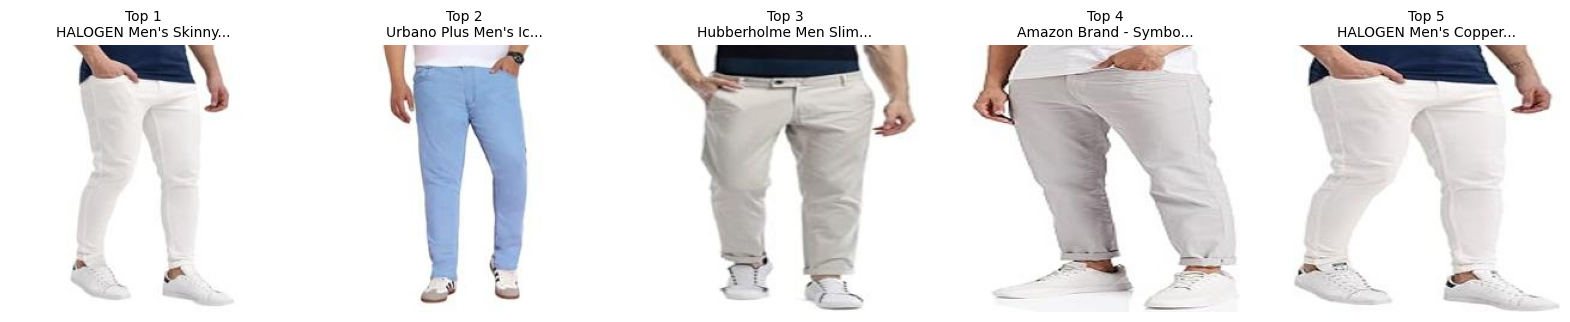

,name,description,image_path_in_local
113,HALOGEN Men's Skinny Fit Jeans,HALOGEN Men's Skinny Fit Jeans,/content/clothes_images/clothesimage/206.jpg
292,Urbano Plus Men's Ice Blue Regular Fit Solid J...,Urbano Plus Men's Ice Blue Regular Fit Solid J...,/content/clothes_images/clothesimage/581.jpg
1756,Hubberholme Men Slim Fit Casual Comfortable St...,Hubberholme Men Slim Fit Casual Comfortable St...,/content/clothes_images/clothesimage/4467.jpg
6622,Amazon Brand - Symbol Men's Regular Casual Tro...,Amazon Brand - Symbol Men's Regular Casual Tro...,/content/clothes_images/clothesimage/17824.jpg
142,HALOGEN Men's Copperstone Slim Fit White Denim...,HALOGEN Men's Copperstone Slim Fit White Denim...,/content/clothes_images/clothesimage/266.jpg


In [32]:
from google.colab import files
import io

def multimodal_search_upload(top_k=5, text_weight=0.5):
    print("Vui lòng chọn 1 ảnh từ máy tính của bạn:")
    uploaded = files.upload()
    if not uploaded:
        print("Không có file nào được tải lên.")
        return

    img_path = list(uploaded.keys())[0]
    query_text = input("Nhập yêu cầu bằng chữ (ví dụ: 'similar but blue'): ")

    model.eval()
    combined_feature = None

    with torch.no_grad():
        # 1. Image Feature
        img = val_transform(Image.open(io.BytesIO(uploaded[img_path])).convert('RGB')).unsqueeze(0).to(device)
        img_feat = model.encode_image(img)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)

        # 2. Text Feature
        if query_text.strip():
            text_tokens = tokenizer([clean_fashion_text(query_text)]).to(device)
            text_feat = model.encode_text(text_tokens)
            text_feat /= text_feat.norm(dim=-1, keepdim=True)
            combined_feature = (img_feat * (1 - text_weight)) + (text_feat * text_weight)
        else:
            combined_feature = img_feat

        combined_feature /= combined_feature.norm(dim=-1, keepdim=True)

    # FAISS Search
    q_vec = combined_feature.cpu().numpy().astype('float32')
    distances, indices = index.search(q_vec, top_k)
    res = df.iloc[indices[0]]

    # Show kết quả
    display_results(f"Kết quả kết hợp ảnh đã tải + '{query_text}'", res)

# Chạy demo
multimodal_search_upload()

# TEST PHASE2


In [33]:
import faiss
import numpy as np
import os
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

def extract_embeddings(model, loader, device):
    model.eval()
    all_features = []
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Đang trích xuất features"):
            images = images.to(device)
            features = model.encode_image(images)
            features /= features.norm(dim=-1, keepdim=True)
            all_features.append(features.cpu().numpy())
    return np.vstack(all_features)

# Nạp trọng số từ quá trình tối ưu mới nhất
optimized_path = "best_model_optimized_v2.pt"
if os.path.exists(optimized_path):
    model.load_state_dict(torch.load(optimized_path, map_location=device))
    print(f"✅ Đã nạp thành công: {optimized_path}")
else:
    if os.path.exists("best_model.pt"):
        model.load_state_dict(torch.load("best_model.pt", map_location=device))
        print("⚠️ Đang sử dụng best_model.pt cũ.")

full_dataset = FashionDataset(df, preprocess, tokenizer)
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=2)

image_embeddings = extract_embeddings(model, full_loader, device)

dimension = image_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(image_embeddings.astype('float32'))

print(f"🚀 Retrieval Index đã sẵn sàng với trọng số mới!")

✅ Đã nạp thành công: best_model_optimized_v2.pt


Đang trích xuất features:   0%|          | 0/192 [00:00<?, ?it/s]

🚀 Retrieval Index đã sẵn sàng với trọng số mới!


Kết quả tìm kiếm cho: 'TSHIRT KTOON FOR MEN'


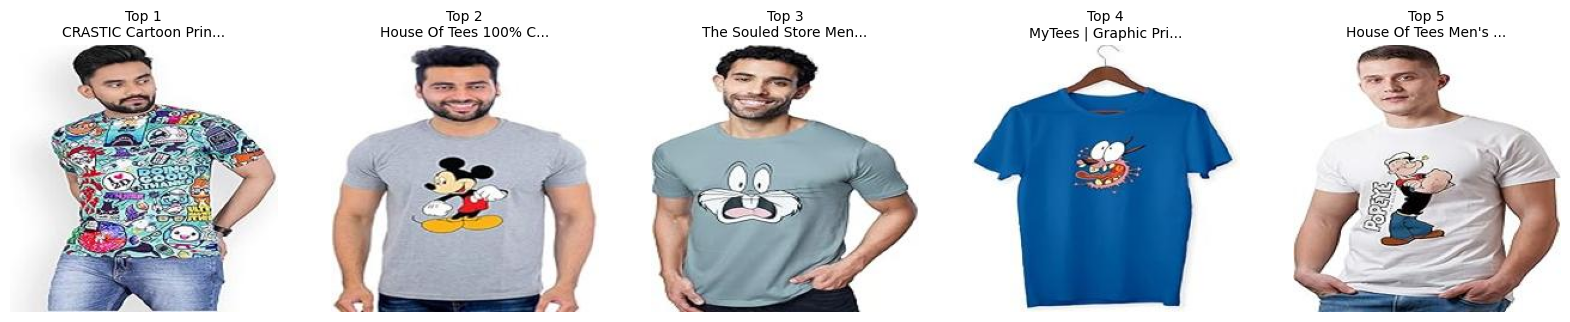

,name,description,image_path_in_local
10015,CRASTIC Cartoon Printed Round Neck Casual Half...,CRASTIC Cartoon Printed Round Neck Casual Half...,/content/clothes_images/clothesimage/26213.jpg
8231,House Of Tees 100% Cotton Cartoon Printed Roun...,House Of Tees 100% Cotton Cartoon Printed Roun...,/content/clothes_images/clothesimage/21416.jpg
10106,The Souled Store Men Official Looney Tunes: Bu...,The Souled Store Men Official Looney Tunes: Bu...,/content/clothes_images/clothesimage/26516.jpg
12187,MyTees | Graphic Printed Tshirt for Men |Funky...,MyTees | Graphic Printed Tshirt for Men |Funky...,/content/clothes_images/clothesimage/32011.jpg
8010,House Of Tees Men's Regular Fit T-Shirt,House Of Tees Men's Regular Fit T-Shirt,/content/clothes_images/clothesimage/20944.jpg


In [50]:
import matplotlib.pyplot as plt
from PIL import Image

# Định nghĩa hàm tìm kiếm (Đảm bảo đã chạy các cell khởi tạo model và index trước đó)
def search_fashion(query_text, top_k=5):
    text_tokens = tokenizer([clean_fashion_text(query_text)]).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    query_vector = text_features.cpu().numpy().astype('float32')
    distances, indices = index.search(query_vector, top_k)
    return df.iloc[indices[0]]

def display_results(query, results):
    print(f"Kết quả tìm kiếm cho: '{query}'")
    plt.figure(figsize=(20, 10))

    for i, (idx, row) in enumerate(results.iterrows()):
        plt.subplot(1, len(results), i + 1)
        try:
            img = Image.open(row['image_path_in_local'])
            plt.imshow(img)
            plt.title(f"Top {i+1}\n{row['name'][:20]}...", fontsize=10)
        except Exception as e:
            plt.title(f"Lỗi tải ảnh")
        plt.axis('off')
    plt.show()

    # Hiển thị thông tin chi tiết
    display(results[['name', 'description', 'image_path_in_local']])

# --- THỰC HIỆN TÌM KIẾM ---
query = "TSHIRT KTOON FOR MEN"
top_results = search_fashion(query, top_k=5)
display_results(query, top_results)

In [35]:
import numpy as np
import torch
from tqdm.auto import tqdm

def evaluate_retrieval(model, df_test, index, tokenizer, device, ks=[1, 5, 10, 20]):
    model.eval()

    # 1. Trích xuất embedding cho toàn bộ mô tả trong tập test
    print("Đang trích xuất text embeddings cho tập test...")
    test_texts = df_test['description'].apply(clean_fashion_text).tolist()
    all_text_features = []

    with torch.no_grad():
        for i in tqdm(range(0, len(test_texts), 64)):
            batch_texts = test_texts[i:i+64]
            text_tokens = tokenizer(batch_texts).to(device)
            text_features = model.encode_text(text_tokens)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            all_text_features.append(text_features.cpu().numpy())

    all_text_features = np.vstack(all_text_features).astype('float32')

    # 2. Tìm kiếm top-max(K) kết quả cho mỗi câu query
    max_k = max(ks)
    distances, indices = index.search(all_text_features, max_k)

    # 3. Tính toán các chỉ số
    test_indices_in_df = df_test.index.values

    recall_at_k = {k: 0 for k in ks}
    mrr = 0
    ndcg_at_k = {k: 0 for k in ks}

    n_queries = len(df_test)

    for i in range(n_queries):
        target_idx = test_indices_in_df[i]
        retrieved_indices = indices[i]

        rank = np.where(retrieved_indices == target_idx)[0]

        if len(rank) > 0:
            rank = rank[0] + 1
            mrr += 1.0 / rank
            for k in ks:
                if rank <= k:
                    recall_at_k[k] += 1
                    ndcg_at_k[k] += 1.0 / np.log2(rank + 1)

    metrics = {"MRR": (mrr / n_queries) * 100}
    for k in ks:
        metrics[f"Recall@{k}"] = (recall_at_k[k] / n_queries) * 100
        metrics[f"NDCG@{k}"] = (ndcg_at_k[k] / n_queries) * 100

    return metrics

# Thực hiện đánh giá trên test_df
results_metrics = evaluate_retrieval(model, test_df, index, tokenizer, device)

print("\n--- KẾT QUẢ ĐÁNH GIÁ ---")
for metric, value in results_metrics.items():
    if "Recall" in metric:
        print(f"{metric:10}: {value:.2f}%")
    else:
        print(f"{metric:10}: {(value / 100):.4f}")


Đang trích xuất text embeddings cho tập test...


  0%|          | 0/20 [00:00<?, ?it/s]


--- KẾT QUẢ ĐÁNH GIÁ ---
MRR       : 0.2116
Recall@1  : 11.80%
NDCG@1    : 0.1180
Recall@5  : 32.38%
NDCG@5    : 0.2229
Recall@10 : 42.55%
NDCG@10   : 0.2556
Recall@20 : 54.84%
NDCG@20   : 0.2866


In [36]:
import pandas as pd

ks = [1, 5, 10, 20]
mrr_value = results_metrics['MRR'] / 100 # Convert MRR to decimal

table_data = {}
for k in ks:
    table_data[f"@{k}"] = {
        "MRR": "" if k != ks[0] else f"{mrr_value:.4f}", # Only show MRR for the first k
        "Recall": f"{results_metrics[f'Recall@{k}']:.2f}%",
        "NDCG": f"{results_metrics[f'NDCG@{k}'] / 100:.4f}" # Convert NDCG to decimal
    }

df_metrics_table = pd.DataFrame.from_dict(table_data, orient='index')
df_metrics_table.index.name = "K"
display(df_metrics_table)


,MRR,Recall,NDCG
K,,,
@1,0.2116,11.80%,0.1180
@5,,32.38%,0.2229
@10,,42.55%,0.2556
@20,,54.84%,0.2866


Vui lòng chọn 1 ảnh từ máy tính của bạn:


Saving quan-au-nam-mau-trang2_ae0f3a10c37b4b86bac74c2a5c67ffcd.jpg to quan-au-nam-mau-trang2_ae0f3a10c37b4b86bac74c2a5c67ffcd (7).jpg
Nhập yêu cầu bằng chữ (ví dụ: 'similar but blue'): light color casual pants 
Kết quả tìm kiếm cho: 'Kết quả kết hợp ảnh đã tải + 'light color casual pants ''


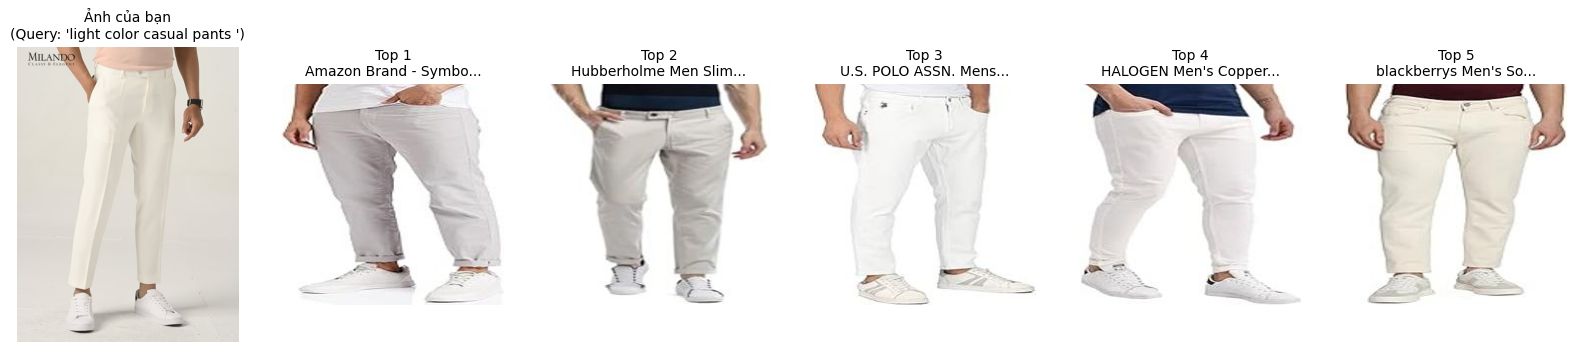

In [66]:
from google.colab import files
import io

def multimodal_search_upload(top_k=5, text_weight=0.5):
    print("Vui lòng chọn 1 ảnh từ máy tính của bạn:")
    uploaded = files.upload()
    if not uploaded:
        print("Không có file nào được tải lên.")
        return

    img_path = list(uploaded.keys())[0]
    uploaded_img_data = uploaded[img_path]
    query_text = input("Nhập yêu cầu bằng chữ (ví dụ: 'similar but blue'): ")

    model.eval()
    combined_feature = None

    with torch.no_grad():
        # 1. Image Feature
        img = val_transform(Image.open(io.BytesIO(uploaded_img_data)).convert('RGB')).unsqueeze(0).to(device)
        img_feat = model.encode_image(img)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)

        # 2. Text Feature
        if query_text.strip():
            text_tokens = tokenizer([clean_fashion_text(query_text)]).to(device)
            text_feat = model.encode_text(text_tokens)
            text_feat /= text_feat.norm(dim=-1, keepdim=True)
            combined_feature = (img_feat * (1 - text_weight)) + (text_feat * text_weight)
        else:
            combined_feature = img_feat

        combined_feature /= combined_feature.norm(dim=-1, keepdim=True)

    # FAISS Search
    q_vec = combined_feature.cpu().numpy().astype('float32')
    distances, indices = index.search(q_vec, top_k)
    res = df.iloc[indices[0]]

    # Show kết quả, truyền cả dữ liệu ảnh đã tải lên
    display_results_with_uploaded_image(uploaded_img_data, f"Kết quả kết hợp ảnh đã tải + '{query_text}'", res)

# Chạy demo
multimodal_search_upload()

Vui lòng chọn 1 ảnh từ máy tính của bạn:


Saving phoi-do-nam-2.jpg to phoi-do-nam-2 (7).jpg
Kết quả tìm kiếm cho: 'Kết quả tìm kiếm cho ảnh đã tải'


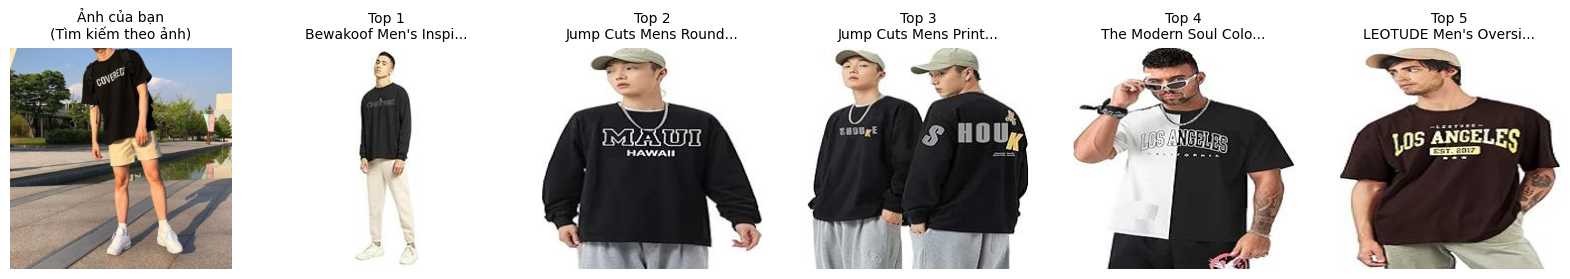

In [64]:
from google.colab import files
import io
import matplotlib.pyplot as plt
from PIL import Image
import torch

def display_results_with_uploaded_image(uploaded_img_data, query, results):
    print(f"Kết quả tìm kiếm cho: '{query}'")
    plt.figure(figsize=(20, 10))

    # Display the uploaded image first
    plt.subplot(1, len(results) + 1, 1)
    try:
        img = Image.open(io.BytesIO(uploaded_img_data))
        plt.imshow(img)
        # Display the query text under the uploaded image, if it exists and is not a default message
        display_query_text = query.replace("Kết quả tìm kiếm cho ảnh đã tải", "")
        display_query_text = display_query_text.replace("Kết quả kết hợp ảnh đã tải + ", "")
        if display_query_text.strip():
            plt.title(f"Ảnh của bạn\n(Query: {display_query_text.strip()})", fontsize=10)
        else:
            plt.title(f"Ảnh của bạn\n(Tìm kiếm theo ảnh)", fontsize=10)
    except Exception as e:
        plt.title(f"Lỗi tải ảnh gốc")
    plt.axis('off')

    # Display search results
    for i, (idx, row) in enumerate(results.iterrows()):
        plt.subplot(1, len(results) + 1, i + 2) # Offset by 1 for the uploaded image
        try:
            img = Image.open(row['image_path_in_local'])
            plt.imshow(img)
            plt.title(f"Top {i+1}\n{row['name'][:20]}...", fontsize=10)
        except Exception as e:
            plt.title(f"Lỗi tải ảnh")
        plt.axis('off')
    plt.show()

def image_search_upload(top_k=5):
    print("Vui lòng chọn 1 ảnh từ máy tính của bạn:")
    uploaded = files.upload()
    if not uploaded:
        print("Không có file nào được tải lên.")
        return

    img_path = list(uploaded.keys())[0]
    uploaded_img_data = uploaded[img_path] # Get the raw image data

    model.eval()

    with torch.no_grad():
        # 1. Image Feature
        img = val_transform(Image.open(io.BytesIO(uploaded_img_data)).convert('RGB')).unsqueeze(0).to(device)
        img_feat = model.encode_image(img)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)

        combined_feature = img_feat
        combined_feature /= combined_feature.norm(dim=-1, keepdim=True)

    # FAISS Search
    q_vec = combined_feature.cpu().numpy().astype('float32')
    distances, indices = index.search(q_vec, top_k)
    res = df.iloc[indices[0]]

    # Show kết quả, truyền cả dữ liệu ảnh đã tải lên
    display_results_with_uploaded_image(uploaded_img_data, "Kết quả tìm kiếm cho ảnh đã tải", res)

image_search_upload()